In [1]:
# import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

#load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(569, 30)
(569,)


In [2]:
# LDA
class LDA:

    def fit(self, X, y):

        self.classes = np.unique(y)

        n_features = X.shape[1]

        self.means = {}
        self.priors = {}

        covariance = np.zeros((n_features, n_features))

        for c in self.classes:

            X_c = X[y == c]

            self.means[c] = np.mean(X_c, axis=0)

            self.priors[c] = X_c.shape[0] / X.shape[0]

            covariance += np.cov(X_c, rowvar=False) * (X_c.shape[0] - 1)

        covariance /= (X.shape[0] - len(self.classes))

        self.covariance = covariance

        self.inv_covariance = np.linalg.inv(covariance)

    def _discriminant(self, x, c):

        mean = self.means[c]

        term1 = x @ self.inv_covariance @ mean

        term2 = -0.5 * mean @ self.inv_covariance @ mean

        term3 = np.log(self.priors[c])

        return term1 + term2 + term3

    def predict(self, X):

        predictions = []

        for x in X:

            scores = [
                self._discriminant(x, c)
                for c in self.classes
            ]

            predictions.append(self.classes[np.argmax(scores)])

        return np.array(predictions)

In [3]:
# Train Model
model = LDA()

model.fit(X_train, y_train)

In [5]:
# Metrics
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.956140350877193
[[39  4]
 [ 1 70]]


In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.956140350877193


In [7]:
#Plot

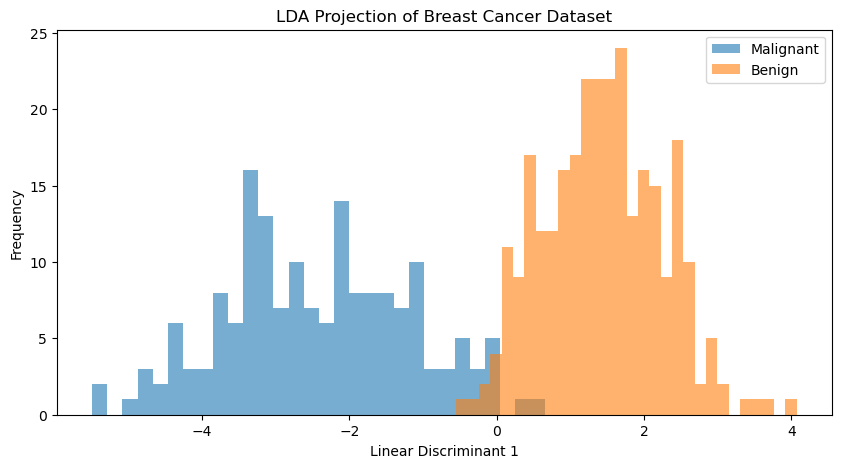

In [8]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA for visualization
lda_vis = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda_vis.fit_transform(X_train, y_train)

plt.figure(figsize=(10, 5))

plt.hist(
    X_lda[y_train == 0],
    bins=30,
    alpha=0.6,
    label="Malignant"
)

plt.hist(
    X_lda[y_train == 1],
    bins=30,
    alpha=0.6,
    label="Benign"
)

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Frequency")
plt.title("LDA Projection of Breast Cancer Dataset")
plt.legend()
plt.show()

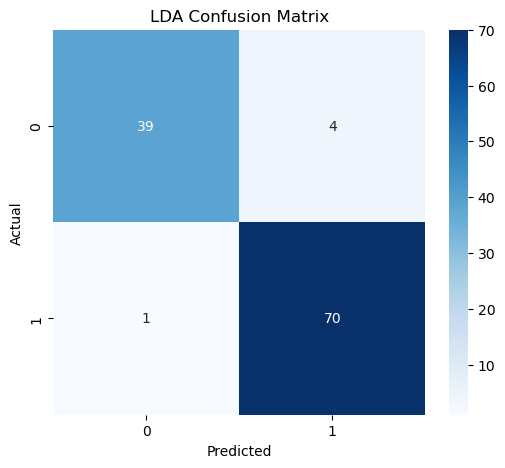

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LDA Confusion Matrix")
plt.show()